# Análise descritiva

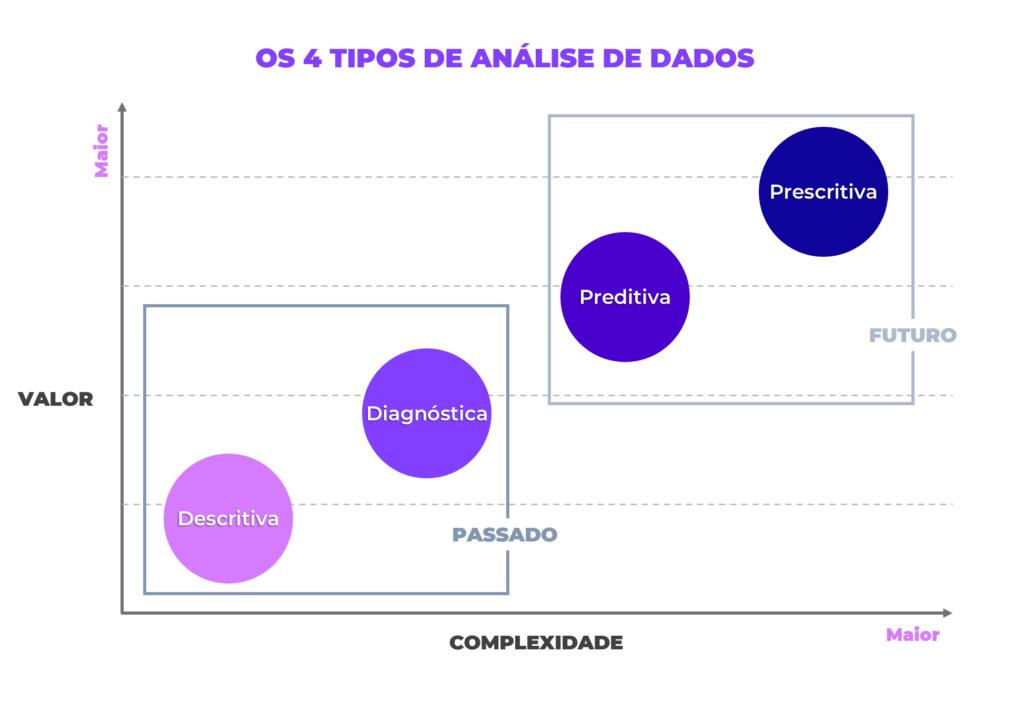

# Importando dados

In [1]:
import pandas as pd
# 3 bases de dados, farei a junção das 3
df_vendas = pd.read_csv('../data-scripts/4/base_dados_vendas_tratada.csv', parse_dates=['dt_entrega', 'dt_venda'])

In [2]:
df_complementares = pd.read_csv('../data-scripts/4/dados_complementares.csv', parse_dates=['dt_entrega', 'dt_venda'])
df_metas = pd.read_excel('../data-scripts/4/Python_JOIN_Metas.xlsx')

# Análise exploratória

In [3]:
df_vendas.head()

,dt_venda,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final
0,2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3
1,2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.4,2,2020-06-11 13:59:00,284.8
2,2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,2,2019-03-28 09:44:00,808.2
3,2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,2,2019-09-20 09:22:00,3418.2
4,2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.0,2,2019-11-26 13:42:00,6398.0


In [4]:
df_vendas['descricao_produto'].count()

np.int64(3000)

In [5]:
df_vendas.info() #não temos valores faltantes

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   dt_venda               3000 non-null   datetime64[us]
 1   matricula_funcionario  3000 non-null   int64         
 2   nome_funcionario       3000 non-null   str           
 3   cargo                  3000 non-null   str           
 4   codigo_loja            3000 non-null   str           
 5   nome_loja              3000 non-null   str           
 6   codigo_produto         3000 non-null   int64         
 7   descricao_produto      3000 non-null   str           
 8   categoria              3000 non-null   str           
 9   preco_custo            3000 non-null   float64       
 10  valor_unitario         3000 non-null   float64       
 11  quantidade             3000 non-null   int64         
 12  dt_entrega             3000 non-null   datetime64[us]
 13  valor_final   

In [6]:
df_vendas.duplicated().sum()

np.int64(0)

In [7]:
df_vendas[['valor_unitario', 'preco_custo', 'valor_final']].describe()

,valor_unitario,preco_custo,valor_final
count,3000.000000,3000.000000,3000.000000
mean,926.941353,545.512300,2234.948870
std,841.839695,563.133526,2449.473528
min,55.900000,27.900000,55.900000
25%,189.900000,109.900000,427.200000
50%,404.100000,210.900000,1346.900000
75%,1424.910000,799.000000,3353.800000
max,3199.000000,2299.900000,12796.000000


In [8]:
df_vendas.describe(include='object')

C:\Users\david\AppData\Local\Temp\ipykernel_12804\310596071.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_vendas.describe(include='object')


,nome_funcionario,cargo,codigo_loja,nome_loja,descricao_produto,categoria
count,3000,3000,3000,3000,3000,3000
unique,12,1,4,4,20,4
top,José Maria,Vendedor,CL001,Loja Matriz,Aspirador de pó,Casa
freq,280,3000,793,793,173,907


# Análise exploratória

In [9]:
df_complementares.info() #não temos valores faltantes

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   dt_venda               500 non-null    datetime64[us]
 1   matricula_funcionario  500 non-null    int64         
 2   nome_funcionario       500 non-null    str           
 3   cargo                  500 non-null    str           
 4   codigo_loja            500 non-null    str           
 5   nome_loja              500 non-null    str           
 6   codigo_produto         500 non-null    int64         
 7   descricao_produto      500 non-null    str           
 8   categoria              500 non-null    str           
 9   preco_custo            500 non-null    float64       
 10  valor_unitario         500 non-null    float64       
 11  quantidade             500 non-null    int64         
 12  dt_entrega             500 non-null    datetime64[us]
 13  valor_final     

In [10]:
df_complementares[['valor_unitario', 'preco_custo', 'valor_final']].describe().round(2)

,valor_unitario,preco_custo,valor_final
count,500.00,500.00,500.00
mean,925.93,550.18,2248.96
std,861.32,581.42,2427.84
min,55.90,27.90,55.90
25%,249.90,110.00,499.80
50%,404.10,210.90,1139.60
75%,1676.90,899.90,3418.20
max,3199.00,2299.90,12796.00


In [11]:
df_complementares.describe(include='object')

C:\Users\david\AppData\Local\Temp\ipykernel_12804\2142836573.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_complementares.describe(include='object')


,nome_funcionario,cargo,codigo_loja,nome_loja,descricao_produto,categoria
count,500,500,500,500,500,500
unique,12,1,4,4,20,4
top,Maria das Graças,Vendedor,CL001,Loja Matriz,Microondas,Eletrodomésticos
freq,60,500,147,147,41,148


In [12]:
display(df_metas)

,ano,mes,meta
0,2019,1,285000
1,2019,2,285000
2,2019,3,285000
3,2019,4,285000
4,2019,5,285000
5,2019,6,285000
6,2019,7,285000
7,2019,8,285000
8,2019,9,285000
9,2019,10,285000


In [13]:
df_metas.info() #não temos valores faltantes

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   ano     24 non-null     int64
 1   mes     24 non-null     int64
 2   meta    24 non-null     int64
dtypes: int64(3)
memory usage: 708.0 bytes


# Concat (join) / novas linhas

In [14]:
df_concate = pd.concat([df_vendas,df_complementares], axis=0, join='inner')

In [15]:
df_concate.shape

(3500, 14)

# Merge (mesclar) / novas linhas

In [16]:
df_concate['ano'] = df_concate['dt_venda'].dt.year
df_concate['mes'] = df_concate['dt_venda'].dt.month

In [17]:
df_merge = df_concate.merge(df_metas, on=['ano', 'mes'], how='inner')

# Feature engineering /  engenharia de dados

In [18]:
display(df_merge)

,dt_venda,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano,mes,meta
0,2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,3,2020-08-31 16:39:00,1212.30,2020,8,285000
1,2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.40,2,2020-06-11 13:59:00,284.80,2020,6,285000
2,2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.10,2,2019-03-28 09:44:00,808.20,2019,3,285000
3,2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,2,2019-09-20 09:22:00,3418.20,2019,9,285000
4,2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.00,2,2019-11-26 13:42:00,6398.00,2019,11,285000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,2019-09-04 00:00:00,123457111,Pamela Lima,Vendedor,CL004,Filial ES,10018,Colchão,Casa,109.9,249.90,3,2019-04-12 09:04:00,749.70,2019,9,285000
3496,2020-05-02 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10017,Cama Box,Casa,1189.9,1899.50,3,2020-03-11 10:27:00,5698.50,2020,5,285000
3497,2020-06-14 00:00:00,123456333,Jorge Mateus,Vendedor,CL001,Loja Matriz,10003,Televisão,Eletrodomésticos,1400.9,2279.99,1,2019-04-07 15:45:00,2279.99,2020,6,285000
3498,2020-11-04 00:00:00,123456111,José Maria,Vendedor,CL001,Loja Matriz,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.10,3,2019-11-05 15:44:00,5127.30,2020,11,285000


In [19]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   dt_venda               3500 non-null   datetime64[us]
 1   matricula_funcionario  3500 non-null   int64         
 2   nome_funcionario       3500 non-null   str           
 3   cargo                  3500 non-null   str           
 4   codigo_loja            3500 non-null   str           
 5   nome_loja              3500 non-null   str           
 6   codigo_produto         3500 non-null   int64         
 7   descricao_produto      3500 non-null   str           
 8   categoria              3500 non-null   str           
 9   preco_custo            3500 non-null   float64       
 10  valor_unitario         3500 non-null   float64       
 11  quantidade             3500 non-null   int64         
 12  dt_entrega             3500 non-null   datetime64[us]
 13  valor_final   

In [20]:
# criando nova coluna margem_lucro
df_merge['margem_lucro'] = (df_merge['valor_unitario'] - df_merge['preco_custo']) / df_merge['valor_unitario']

df_merge['margem_lucro'].head()

0    0.478099
1    0.579354
2    0.478099
3    0.356972
4    0.281057
Name: margem_lucro, dtype: float64

In [21]:
# criando nova coluna lucro
df_merge['lucro'] = df_merge['valor_final'] - (df_merge['preco_custo'] * df_merge['quantidade'])

df_merge['lucro'].head()

0     579.6
1     165.0
2     386.4
3    1220.2
4    1798.2
Name: lucro, dtype: float64

In [22]:
# removendo colunas
df_merge = df_merge.drop(columns=['matricula_funcionario', 'codigo_produto'])
df_merge = df_merge.drop(columns=['codigo_loja'])

In [23]:
df_merge.head().round(2)

C:\Users\david\AppData\Local\Temp\ipykernel_12804\2889359869.py:1: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_merge.head().round(2)


,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano,mes,meta,margem_lucro,lucro
0,2020-08-25 10:04:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3,2020,8,285000,0.48,579.6
1,2020-06-10 15:34:00,Felipe Marinho,Vendedor,Filial SP,Liquidificador,Cozinha,59.9,142.4,2,2020-06-11 13:59:00,284.8,2020,6,285000,0.58,165.0
2,2019-03-21 15:58:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.1,2,2019-03-28 09:44:00,808.2,2019,3,285000,0.48,386.4
3,2019-09-16 14:46:00,Felipe Marinho,Vendedor,Filial SP,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,2,2019-09-20 09:22:00,3418.2,2019,9,285000,0.36,1220.2
4,2019-11-25 16:28:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,2,2019-11-26 13:42:00,6398.0,2019,11,285000,0.28,1798.2


In [24]:
# nova coluna
df_merge['tempo_entrega'] = (df_merge['dt_entrega'] - df_merge['dt_venda']).dt.days

display(df_merge['tempo_entrega'])
#alguns valores estão invertidos

0         6
1         0
2         6
3         3
4         0
       ... 
3495   -145
3496    -52
3497   -434
3498   -365
3499   -151
Name: tempo_entrega, Length: 3500, dtype: int64

# Filtros

## Loc
- localiza a partir do índice

In [25]:
# localizamos a linha nº 500
df_filtrado = df_merge.loc[500]
df_filtrado

dt_venda             2019-10-03 13:37:00
nome_funcionario            Jorge Mateus
cargo                           Vendedor
nome_loja                    Loja Matriz
descricao_produto             Impressora
categoria                    Eletrônicos
preco_custo                        329.9
valor_unitario                     674.1
quantidade                             3
dt_entrega           2019-10-03 14:16:00
valor_final                       2022.3
ano                                 2019
mes                                   10
meta                              285000
margem_lucro                    0.510607
lucro                             1032.6
tempo_entrega                          0
Name: 500, dtype: object

In [26]:
# localizamos da linha nº 250 até a linha 500
df_filtrado = df_merge.loc[250:500]
df_filtrado

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano,mes,meta,margem_lucro,lucro,tempo_entrega
250,2020-03-12 16:41:00,Felipe Marinho,Vendedor,Filial SP,Liquidificador,Cozinha,59.9,142.40,4,2020-03-13 13:51:00,569.60,2020,3,285000,0.579354,330.00,0
251,2020-12-06 11:07:00,Felipe Marinho,Vendedor,Filial SP,Tablet,Eletrônicos,799.0,1424.91,1,2020-12-06 16:17:00,1424.91,2020,12,285000,0.439263,625.91,0
252,2020-12-09 13:07:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.10,1,2020-12-12 14:30:00,404.10,2020,12,285000,0.478099,193.20,3
253,2020-11-24 14:16:00,Felipe Marinho,Vendedor,Filial SP,Guarda Roupa,Casa,489.9,999.00,4,2020-11-28 14:30:00,3996.00,2020,11,285000,0.509610,2036.40,4
254,2019-01-25 16:49:00,Felipe Marinho,Vendedor,Filial SP,Processador de alimentos,Cozinha,110.0,189.90,4,2019-01-26 11:49:00,759.60,2019,1,285000,0.420748,319.60,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,2019-02-22 17:59:00,Jorge Mateus,Vendedor,Loja Matriz,Tablet,Eletrônicos,799.0,1424.91,1,2019-02-23 12:32:00,1424.91,2019,2,285000,0.439263,625.91,0
497,2020-07-02 11:15:00,Jorge Mateus,Vendedor,Loja Matriz,Smartphone,Eletrônicos,899.9,1676.90,3,2020-07-03 11:07:00,5030.70,2020,7,285000,0.463355,2331.00,0
498,2020-12-07 12:19:00,Jorge Mateus,Vendedor,Loja Matriz,Smartphone,Eletrônicos,899.9,1676.90,3,2020-12-07 15:49:00,5030.70,2020,12,285000,0.463355,2331.00,0
499,2020-02-16 10:55:00,Jorge Mateus,Vendedor,Loja Matriz,Batedeira,Cozinha,49.9,95.90,4,2020-02-16 16:56:00,383.60,2020,2,285000,0.479666,184.00,0


In [27]:
# escolhendo uma coluna como índice
df_vendas = pd.read_csv('../data-scripts/4/base_dados_vendas_tratada.csv', parse_dates=['dt_venda', 'dt_entrega'], index_col='dt_venda')
df_vendas.head()

,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final
dt_venda,,,,,,,,,,,,,
2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3
2020-06-10 15:34:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.4,2,2020-06-11 13:59:00,284.8
2019-03-21 15:58:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,2,2019-03-28 09:44:00,808.2
2019-09-16 14:46:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10004,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,2,2019-09-20 09:22:00,3418.2
2019-11-25 16:28:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10005,Notebook,Eletrônicos,2299.9,3199.0,2,2019-11-26 13:42:00,6398.0


In [28]:
df_filtrado = df_vendas.loc['2020-08']
display(df_filtrado)

,matricula_funcionario,nome_funcionario,cargo,codigo_loja,nome_loja,codigo_produto,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final
dt_venda,,,,,,,,,,,,,
2020-08-25 10:04:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10013,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3
2020-08-31 12:54:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10015,Microondas,Eletrodomésticos,189.0,364.5,2,2020-09-01 09:20:00,729.0
2020-08-30 09:06:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10014,Geladeira,Eletrodomésticos,699.9,1346.9,3,2020-09-02 15:04:00,4040.7
2020-08-27 15:56:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10006,Aspirador de pó,Casa,88.9,189.9,3,2020-08-28 12:34:00,569.7
2020-08-13 09:15:00,123456999,Felipe Marinho,Vendedor,CL003,Filial SP,10011,Liquidificador,Cozinha,59.9,142.4,3,2020-08-13 15:05:00,427.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-28 10:08:00,123457113,Victor Hugo,Vendedor,CL004,Filial ES,10015,Microondas,Eletrodomésticos,189.0,364.5,2,2020-08-28 14:22:00,729.0
2020-08-24 13:34:00,123457113,Victor Hugo,Vendedor,CL004,Filial ES,10011,Liquidificador,Cozinha,59.9,142.4,2,2020-08-25 12:27:00,284.8
2020-08-09 14:22:00,123457113,Victor Hugo,Vendedor,CL004,Filial ES,10015,Microondas,Eletrodomésticos,189.0,364.5,2,2020-08-10 14:21:00,729.0


## Lógico
- Operadores lógicos e de comparação
```
E and (&)
OU or (|)
NÃO not (~)

> maior que
< menor que
>= maior ou igual que
<= menor ou igual que
== igual a
!= diferente de
```



In [29]:
filtro1 = df_merge['valor_final'] >= 12796
df_merge[filtro1].info()

<class 'pandas.DataFrame'>
Index: 27 entries, 142 to 3265
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dt_venda           27 non-null     datetime64[us]
 1   nome_funcionario   27 non-null     str           
 2   cargo              27 non-null     str           
 3   nome_loja          27 non-null     str           
 4   descricao_produto  27 non-null     str           
 5   categoria          27 non-null     str           
 6   preco_custo        27 non-null     float64       
 7   valor_unitario     27 non-null     float64       
 8   quantidade         27 non-null     int64         
 9   dt_entrega         27 non-null     datetime64[us]
 10  valor_final        27 non-null     float64       
 11  ano                27 non-null     int32         
 12  mes                27 non-null     int32         
 13  meta               27 non-null     int64         
 14  margem_lucro       27 no

In [30]:
filtro2 = df_merge['nome_loja'] == 'Filial SP'
df_merge[filtro2]

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano,mes,meta,margem_lucro,lucro,tempo_entrega
0,2020-08-25 10:04:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3,2020,8,285000,0.478099,579.6,6
1,2020-06-10 15:34:00,Felipe Marinho,Vendedor,Filial SP,Liquidificador,Cozinha,59.9,142.4,2,2020-06-11 13:59:00,284.8,2020,6,285000,0.579354,165.0,0
2,2019-03-21 15:58:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.1,2,2019-03-28 09:44:00,808.2,2019,3,285000,0.478099,386.4,6
3,2019-09-16 14:46:00,Felipe Marinho,Vendedor,Filial SP,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,2,2019-09-20 09:22:00,3418.2,2019,9,285000,0.356972,1220.2,3
4,2019-11-25 16:28:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,2,2019-11-26 13:42:00,6398.0,2019,11,285000,0.281057,1798.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3462,2019-10-21 00:00:00,Felipe Marinho,Vendedor,Filial SP,Cafeteira,Cozinha,159.9,284.9,2,2019-07-21 09:09:00,569.8,2019,10,285000,0.438750,250.0,-92
3468,2020-02-20 00:00:00,Rita Sampaio,Vendedor,Filial SP,Processador de alimentos,Cozinha,110.0,189.9,4,2019-02-11 17:59:00,759.6,2020,2,285000,0.420748,319.6,-374
3475,2019-08-13 00:00:00,Rita Sampaio,Vendedor,Filial SP,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,4,2020-01-23 12:44:00,6836.4,2019,8,285000,0.356972,2440.4,163
3480,2020-10-18 00:00:00,Rita Sampaio,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,2,2019-10-26 10:07:00,6398.0,2020,10,285000,0.281057,1798.2,-358


In [31]:
df_merge[filtro1 & filtro2]

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano,mes,meta,margem_lucro,lucro,tempo_entrega
142,2019-05-01 09:56:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,4,2019-05-02 09:52:00,12796.0,2019,5,285000,0.281057,3596.4,0
958,2019-08-29 10:44:00,Marcos Coelho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,4,2019-08-29 13:56:00,12796.0,2019,8,285000,0.281057,3596.4,0


## Query

In [32]:
df_merge.query("nome_loja == 'Filial SP'")

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano,mes,meta,margem_lucro,lucro,tempo_entrega
0,2020-08-25 10:04:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.1,3,2020-08-31 16:39:00,1212.3,2020,8,285000,0.478099,579.6,6
1,2020-06-10 15:34:00,Felipe Marinho,Vendedor,Filial SP,Liquidificador,Cozinha,59.9,142.4,2,2020-06-11 13:59:00,284.8,2020,6,285000,0.579354,165.0,0
2,2019-03-21 15:58:00,Felipe Marinho,Vendedor,Filial SP,Fogão,Eletrodomésticos,210.9,404.1,2,2019-03-28 09:44:00,808.2,2019,3,285000,0.478099,386.4,6
3,2019-09-16 14:46:00,Felipe Marinho,Vendedor,Filial SP,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,2,2019-09-20 09:22:00,3418.2,2019,9,285000,0.356972,1220.2,3
4,2019-11-25 16:28:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,2,2019-11-26 13:42:00,6398.0,2019,11,285000,0.281057,1798.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3462,2019-10-21 00:00:00,Felipe Marinho,Vendedor,Filial SP,Cafeteira,Cozinha,159.9,284.9,2,2019-07-21 09:09:00,569.8,2019,10,285000,0.438750,250.0,-92
3468,2020-02-20 00:00:00,Rita Sampaio,Vendedor,Filial SP,Processador de alimentos,Cozinha,110.0,189.9,4,2019-02-11 17:59:00,759.6,2020,2,285000,0.420748,319.6,-374
3475,2019-08-13 00:00:00,Rita Sampaio,Vendedor,Filial SP,Máquina Lavar Roupa,Eletrodomésticos,1099.0,1709.1,4,2020-01-23 12:44:00,6836.4,2019,8,285000,0.356972,2440.4,163
3480,2020-10-18 00:00:00,Rita Sampaio,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,2,2019-10-26 10:07:00,6398.0,2020,10,285000,0.281057,1798.2,-358


In [33]:
df_merge.query('valor_final > 10000').info()

<class 'pandas.DataFrame'>
Index: 27 entries, 142 to 3265
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   dt_venda           27 non-null     datetime64[us]
 1   nome_funcionario   27 non-null     str           
 2   cargo              27 non-null     str           
 3   nome_loja          27 non-null     str           
 4   descricao_produto  27 non-null     str           
 5   categoria          27 non-null     str           
 6   preco_custo        27 non-null     float64       
 7   valor_unitario     27 non-null     float64       
 8   quantidade         27 non-null     int64         
 9   dt_entrega         27 non-null     datetime64[us]
 10  valor_final        27 non-null     float64       
 11  ano                27 non-null     int32         
 12  mes                27 non-null     int32         
 13  meta               27 non-null     int64         
 14  margem_lucro       27 no

In [34]:
df_merge.query('valor_final > 10000 and nome_loja == "Filial SP"')

,dt_venda,nome_funcionario,cargo,nome_loja,descricao_produto,categoria,preco_custo,valor_unitario,quantidade,dt_entrega,valor_final,ano,mes,meta,margem_lucro,lucro,tempo_entrega
142,2019-05-01 09:56:00,Felipe Marinho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,4,2019-05-02 09:52:00,12796.0,2019,5,285000,0.281057,3596.4,0
958,2019-08-29 10:44:00,Marcos Coelho,Vendedor,Filial SP,Notebook,Eletrônicos,2299.9,3199.0,4,2019-08-29 13:56:00,12796.0,2019,8,285000,0.281057,3596.4,0


## Agrupamento

In [35]:
# Agrupando duas colunas e ordenando os dados obtidos em ordem decrescente
df_qtd_produto = df_merge.groupby('descricao_produto')['quantidade'].sum().reset_index().sort_values(by='quantidade', ascending=False)

display(df_qtd_produto)

,descricao_produto,quantidade
0,Aspirador de pó,521
12,Microondas,486
5,Ferro de passar,481
7,Fritadeira elétrica,464
6,Fogão,463
11,Liquidificador,454
13,Máquina Lavar Roupa,453
18,Tablet,444
10,Impressora,444
4,Colchão,430


In [36]:
df_lucro = df_merge.groupby('descricao_produto')['lucro'].sum().reset_index().sort_values(by='lucro', ascending=False)

display(df_lucro)

,descricao_produto,lucro
19,Televisão,372734.16
16,Smartphone,331779.00
14,Notebook,329969.70
3,Cama Box,294484.00
18,Tablet,277904.04
13,Máquina Lavar Roupa,276375.30
8,Geladeira,251036.00
9,Guarda Roupa,214840.20
17,Sofá,212575.90
10,Impressora,152824.80


In [37]:
df_margem_lucro = df_merge.groupby('nome_funcionario')['lucro'].sum().reset_index().sort_values(by='lucro', ascending=False)

display(df_margem_lucro)

,nome_funcionario,lucro
4,Maria das Graças,311164.42
2,José Maria,310298.26
0,Felipe Marinho,283624.88
11,Victor Hugo,268997.57
7,Pamela Lima,266392.10
10,Rita Sampaio,266322.73
6,Mário Henrique,265365.75
5,Marta Cury,259784.24
1,Jorge Mateus,253738.04
8,Reginaldo Sodré,253534.39


In [38]:
df_margem_vfinal = df_merge.groupby('nome_funcionario')['valor_final'].sum().reset_index().sort_values(by='valor_final', ascending=False)

display(df_margem_vfinal)

,nome_funcionario,valor_final
2,José Maria,769628.66
4,Maria das Graças,768765.52
0,Felipe Marinho,676213.98
6,Mário Henrique,661754.15
7,Pamela Lima,656664.60
10,Rita Sampaio,647103.53
11,Victor Hugo,639941.37
1,Jorge Mateus,630363.14
5,Marta Cury,621332.54
8,Reginaldo Sodré,612214.89


In [39]:
df_marg_lucro = df_merge.groupby('nome_funcionario')['margem_lucro'].mean().sort_values(ascending=False)

display(df_marg_lucro)

nome_funcionario
Marcos Coelho       0.469561
Victor Hugo         0.467608
Marta Cury          0.466065
Felipe Marinho      0.462066
Ricardo Lemos       0.461322
Jorge Mateus        0.457347
Reginaldo Sodré     0.457293
Mário Henrique      0.455709
Rita Sampaio        0.455544
Maria das Graças    0.455384
Pamela Lima         0.454047
José Maria          0.452581
Name: margem_lucro, dtype: float64

In [40]:
df_func_prod = df_merge.groupby(['nome_funcionario', 'descricao_produto'])['valor_final'].sum().reset_index().sort_values(by='valor_final', ascending=False)

display(df_func_prod)

,nome_funcionario,descricao_produto,valor_final
94,Maria das Graças,Notebook,166348.0
54,José Maria,Notebook,143955.0
34,Jorge Mateus,Notebook,134358.0
134,Mário Henrique,Notebook,131159.0
154,Pamela Lima,Notebook,115164.0
...,...,...,...
121,Mário Henrique,Batedeira,1726.2
205,Rita Sampaio,Ferro de passar,1621.1
225,Victor Hugo,Ferro de passar,1509.3
185,Ricardo Lemos,Ferro de passar,1509.3


In [41]:
df_func_prod = df_merge.groupby(['nome_funcionario', 'descricao_produto'])['valor_final'].sum()

display(df_func_prod)

nome_funcionario  descricao_produto       
Felipe Marinho    Aspirador de pó              7596.00
                  Batedeira                    2972.90
                  Cafeteira                   13390.30
                  Cama Box                    56985.00
                  Colchão                     12245.10
                                                ...   
Victor Hugo       Processador de alimentos     8735.40
                  Smartphone                  80491.20
                  Sofá                        37773.00
                  Tablet                      38472.57
                  Televisão                   91199.60
Name: valor_final, Length: 240, dtype: float64

## Gráficos

In [42]:
import plotly.express as px
# demonstração dos diferentes tipos de gráficos desta biblioteca

### Barra

In [43]:
receita_lojas = df_merge.groupby('nome_loja')['valor_final'].sum().reset_index().sort_values(by='valor_final')

fig = px.bar(receita_lojas, x='nome_loja', y='valor_final', text=receita_lojas['valor_final'], title='Receita por Loja', color_discrete_sequence=px.colors.qualitative.Bold)

fig.update_traces(textposition='outside', texttemplate='R$ %{text:0.3s}')

fig.show()

In [44]:
fig = px.bar(df_qtd_produto, x='descricao_produto', y='quantidade', text=df_qtd_produto['quantidade'], color_discrete_sequence=px.colors.sequential.Hot, title='Quantidade de produtos vendidos')
fig.show()

### Pizza

In [45]:
pizza = df_merge.groupby('descricao_produto')['valor_final'].sum().reset_index().sort_values(by='valor_final')

fig = px.pie(pizza.head(), names='descricao_produto', values='valor_final', hole=0.45, height=400, width=600)

fig.show()

### Linha

In [46]:
vendas_mensais = df_merge.groupby([df_merge['dt_venda'].dt.to_period('M')])['valor_final'].sum().reset_index()

vendas_mensais['dt_venda'] = vendas_mensais['dt_venda'].dt.to_timestamp()

fig = px.line(vendas_mensais, x='dt_venda', y='valor_final')

fig.show()

### Dispersão

In [47]:
bolha = df_merge.groupby('descricao_produto').agg({
    'valor_final':'sum',
    'lucro':'sum',
    'quantidade':'sum'
}).reset_index()

fig = px.scatter(bolha, x='lucro', y='valor_final')

fig.show()

In [48]:
bolha = df_merge.groupby('descricao_produto').agg({
    'valor_final':'sum',
    'lucro':'sum',
    'quantidade':'sum'
}).reset_index()

fig = px.scatter(bolha, x='lucro', y='valor_final', color=bolha['descricao_produto'])

fig.show()

### Bolha

In [49]:
bolha = df_merge.groupby('descricao_produto').agg({
    'valor_final':'sum',
    'lucro':'sum',
    'quantidade':'sum'
}).reset_index()

fig = px.scatter(bolha, x='quantidade', y='valor_final', color=bolha['descricao_produto'], size='lucro', size_max=25)

fig.show()

### Árvore

In [50]:
arvore = df_merge.groupby(['nome_loja', 'nome_funcionario', 'descricao_produto'])['lucro'].sum().reset_index()

fig = px.treemap(arvore, path=[px.Constant('Lojas'), 'nome_loja', 'nome_funcionario', 'descricao_produto'], values='lucro')

fig.show()

In [51]:
arvore = df_merge.groupby(['nome_loja', 'nome_funcionario', 'descricao_produto'])['lucro'].sum().reset_index()

fig = px.sunburst(arvore, path=[px.Constant('Lojas'), 'nome_loja', 'nome_funcionario', 'descricao_produto'], values='lucro')

fig.show()

# Airbnb

## Importando Dados

In [52]:
df_bnb = pd.read_csv('../data-scripts/4/listingsairbnb.csv', parse_dates=['last_review'])


## Análise exploratória

In [53]:
df_bnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",68997,Matthias,NaN,Copacabana,-22.96599,-43.17940,Entire home/apt,254.0,5,338,2025-06-25,1.86,1,225,19,NaN
1,25026,Beautiful Modern Decorated Studio in Copacabana,102840,Viviane,NaN,Copacabana,-22.97649,-43.19122,Entire home/apt,252.0,2,313,2025-06-23,1.71,1,193,23,NaN
2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,153691,Patricia Miranda & Paulo,NaN,Copacabana,-22.98107,-43.19136,Entire home/apt,190.0,3,516,2025-06-05,2.88,1,103,41,NaN
3,48305,Bright 6bed Penthouse Seconds from Beach,70933,Goitaca,NaN,Ipanema,-22.98591,-43.20302,Entire home/apt,2239.0,7,183,2025-02-25,1.05,6,351,5,NaN
4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,222884,Marcio,NaN,Copacabana,-22.96574,-43.17514,Entire home/apt,743.0,3,48,2025-06-13,0.40,1,311,17,NaN


In [54]:
df_bnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 42572 entries, 0 to 42571
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              42572 non-null  int64         
 1   name                            42572 non-null  str           
 2   host_id                         42572 non-null  int64         
 3   host_name                       41092 non-null  str           
 4   neighbourhood_group             0 non-null      float64       
 5   neighbourhood                   42572 non-null  str           
 6   latitude                        42572 non-null  float64       
 7   longitude                       42572 non-null  float64       
 8   room_type                       42572 non-null  str           
 9   price                           38992 non-null  float64       
 10  minimum_nights                  42572 non-null  int64         
 11  number_of_rev

In [55]:
df_bnb.describe().round(2)

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,4.257200e+04,4.257200e+04,0.0,42572.00,42572.00,38992.00,42572.00,42572.00,33949,33949.00,42572.00,42572.00,42572.00,0.0
mean,7.837189e+17,2.315791e+08,NaN,-22.97,-43.25,688.01,3.64,25.12,2025-01-01 01:04:25.845827,1.20,9.64,199.26,8.89,NaN
min,1.787800e+04,3.607000e+03,NaN,-23.07,-43.72,34.00,1.00,0.00,2012-02-21 00:00:00,0.01,1.00,0.00,0.00,NaN
25%,4.786936e+07,3.656636e+07,NaN,-22.98,-43.30,200.00,1.00,1.00,2025-03-05 00:00:00,0.28,1.00,88.00,0.00,NaN
50%,9.993601e+17,1.550753e+08,NaN,-22.97,-43.19,311.00,2.00,7.00,2025-05-05 00:00:00,0.78,2.00,182.00,3.00,NaN
75%,1.284331e+18,4.253404e+08,NaN,-22.95,-43.18,558.00,3.00,28.00,2025-06-14 00:00:00,1.74,5.00,338.00,13.00,NaN
max,1.450245e+18,7.030729e+08,NaN,-22.75,-43.10,500000.00,1000.00,744.00,2025-07-03 00:00:00,15.39,226.00,365.00,165.00,NaN
std,5.521959e+17,2.152555e+08,NaN,0.04,0.10,3758.45,14.80,47.33,NaN,1.27,25.66,126.36,13.09,NaN


In [56]:
df_bnb.describe(include='object')

C:\Users\david\AppData\Local\Temp\ipykernel_12804\1189370580.py:1: Pandas4Warning:

For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.



,name,host_name,neighbourhood,room_type
count,42572,41092,42572,42572
unique,40290,7058,154,4
top,Apartamento em Copacabana,Daniel,Copacabana,Entire home/apt
freq,174,431,13099,33990


In [57]:
df_bnb.duplicated().sum()

np.int64(0)

## Missing values

In [58]:
df_bnb['price'] = df_bnb['price'].fillna(0)
df_bnb['reviews_per_month'] = df_bnb['reviews_per_month'].fillna(0)


In [59]:
df_bnb['host_name'] = df_bnb['host_name'].fillna('Not informed')

In [60]:
df_bnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 42572 entries, 0 to 42571
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              42572 non-null  int64         
 1   name                            42572 non-null  str           
 2   host_id                         42572 non-null  int64         
 3   host_name                       42572 non-null  str           
 4   neighbourhood_group             0 non-null      float64       
 5   neighbourhood                   42572 non-null  str           
 6   latitude                        42572 non-null  float64       
 7   longitude                       42572 non-null  float64       
 8   room_type                       42572 non-null  str           
 9   price                           42572 non-null  float64       
 10  minimum_nights                  42572 non-null  int64         
 11  number_of_rev

In [61]:
display(df_bnb)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",68997,Matthias,NaN,Copacabana,-22.965990,-43.179400,Entire home/apt,254.0,5,338,2025-06-25,1.86,1,225,19,NaN
1,25026,Beautiful Modern Decorated Studio in Copacabana,102840,Viviane,NaN,Copacabana,-22.976490,-43.191220,Entire home/apt,252.0,2,313,2025-06-23,1.71,1,193,23,NaN
2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,153691,Patricia Miranda & Paulo,NaN,Copacabana,-22.981070,-43.191360,Entire home/apt,190.0,3,516,2025-06-05,2.88,1,103,41,NaN
3,48305,Bright 6bed Penthouse Seconds from Beach,70933,Goitaca,NaN,Ipanema,-22.985910,-43.203020,Entire home/apt,2239.0,7,183,2025-02-25,1.05,6,351,5,NaN
4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,222884,Marcio,NaN,Copacabana,-22.965740,-43.175140,Entire home/apt,743.0,3,48,2025-06-13,0.40,1,311,17,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42567,1450108622211032237,Aconchego Constante,703072927,Marco,NaN,Copacabana,-22.974055,-43.189129,Entire home/apt,186.0,2,0,NaT,0.00,1,137,0,NaN
42568,1450108828266063076,Quarto casal,320682549,Anna,NaN,Camorim,-22.979640,-43.423380,Private room,288.0,1,0,NaT,0.00,1,365,0,NaN
42569,1450124185987579534,Cama em Dorm Misto (9) com AC,37776540,Mariana,NaN,Ipanema,-22.983102,-43.208741,Shared room,87.0,1,0,NaT,0.00,8,213,0,NaN
42570,1450124362124784419,Quarto para casal,378959794,Anna,NaN,Camorim,-22.984526,-43.431740,Private room,240.0,1,0,NaT,0.00,1,365,0,NaN


In [62]:
df_bnb.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group               42572
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                        8623
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           42572
dtype: int64

## Feature engineering / engenharia de dados

In [63]:
# removendo duas colunas com nenhuma informação
df_bnb = df_bnb.drop(columns=['neighbourhood_group', 'license'])
df_bnb.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,17878,"Very Nice 2Br in Copacabana w. balcony, fast WiFi",68997,Matthias,Copacabana,-22.96599,-43.17940,Entire home/apt,254.0,5,338,2025-06-25,1.86,1,225,19
1,25026,Beautiful Modern Decorated Studio in Copacabana,102840,Viviane,Copacabana,-22.97649,-43.19122,Entire home/apt,252.0,2,313,2025-06-23,1.71,1,193,23
2,35764,COPACABANA SEA BREEZE - RIO - 25 X Superhost,153691,Patricia Miranda & Paulo,Copacabana,-22.98107,-43.19136,Entire home/apt,190.0,3,516,2025-06-05,2.88,1,103,41
3,48305,Bright 6bed Penthouse Seconds from Beach,70933,Goitaca,Ipanema,-22.98591,-43.20302,Entire home/apt,2239.0,7,183,2025-02-25,1.05,6,351,5
4,48901,Extra large 4BD 3BT on the AtlanticAve. Copaca...,222884,Marcio,Copacabana,-22.96574,-43.17514,Entire home/apt,743.0,3,48,2025-06-13,0.40,1,311,17


In [64]:
df_bnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 42572 entries, 0 to 42571
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              42572 non-null  int64         
 1   name                            42572 non-null  str           
 2   host_id                         42572 non-null  int64         
 3   host_name                       42572 non-null  str           
 4   neighbourhood                   42572 non-null  str           
 5   latitude                        42572 non-null  float64       
 6   longitude                       42572 non-null  float64       
 7   room_type                       42572 non-null  str           
 8   price                           42572 non-null  float64       
 9   minimum_nights                  42572 non-null  int64         
 10  number_of_reviews               42572 non-null  int64         
 11  last_review  